# Simple Univariate Linear Regression Example with Linear Model / Fit

- Generate data:

$$𝑦 = 15 𝑥 + 5 + noise $$

- Then try to learn:

$$ \hat{𝑦} = 𝑤_0 + 𝑤_1 𝑥$$

- Using gradient descent to minimize squared error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize Random Number Generator

The `np.random.default_rng()`constructor initializes a random number generator in modern NumPy (version 1.17 and later) by instantiating a `Generator` object that provides access to a wide range of probability distributions and random sampling methods.

Unlike the legacy `np.random.seed()`, which sets a global state that can be unintentionally modified by other libraries, `np.random.default_rng()` creates an independent instance. This isolation ensures better reproducibility and modularity.

You can pass a seed (e.g., `np.random.default_rng(42)`) to ensure the sequence of random numbers is the same every time you run your code.

In [2]:
np.random.default_rng(42)

Generator(PCG64) at 0x2BEB06E4C80

In [3]:
# generate 10 random numbers from a normal (Gaussian) distribution with mean as 0 and standard devation as 0.4
np.random.normal(0, 0.4, 10)

array([-0.06726392,  0.13932753,  0.05480885, -0.06161359,  0.32934412,
       -0.50644786,  0.56475528, -0.03880096,  0.33205453,  0.24648101])

`np.random.normal(0, 0.4, 10)` samples from a normal distribution, which is:
- Unbounded → it can theoretically produce values from −∞ to +∞.
- So there is no guaranteed minimum or maximum.

Even though it's unbounded, most values fall in predictable ranges:
- 68% within ±0.4
- 95% within ±0.8
- 99.7% within ±1.2

## Data Generation

`np.linspace` generates a sequence of $N$ evenly spaced numbers between a specified start and end value.

**Syntax**:
```python
numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
```

**Parameters**:
- `start`: Starting value.
- `stop` : Ending value.
- `num` : number of points (default = 50)

In [4]:
m = 51
x = np.linspace(0, 1, m)
x

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ])

In [5]:
y = 15*x + 5 + np.random.normal(0, 0.4, len(x))
y

array([ 5.06035833,  5.54559838,  5.0677259 ,  6.0560649 ,  5.99866939,
        6.723484  ,  6.41700909,  7.46455917,  6.5438693 ,  8.1815943 ,
        7.88334824,  8.08131769,  8.57960972,  8.43848752,  9.31065325,
        9.27948783,  9.07050976, 10.42745104, 10.09527021, 10.76662039,
       10.61044793, 11.35009902, 11.30318229, 11.42276866, 12.33823116,
       12.54098818, 12.83498984, 13.20887384, 13.6703008 , 14.16334299,
       14.44736931, 13.6652459 , 14.46696658, 14.81277479, 15.73940586,
       16.02976799, 15.58580888, 15.92483655, 16.32184229, 16.73117657,
       16.22883591, 17.42543957, 17.71217039, 18.47799466, 18.08077016,
       18.31533688, 18.62799305, 19.43745747, 19.36175547, 19.44345421,
       20.18154583])

## Visualize the generated data

Text(0.5, 1.0, 'Scatter plot of Generated data')

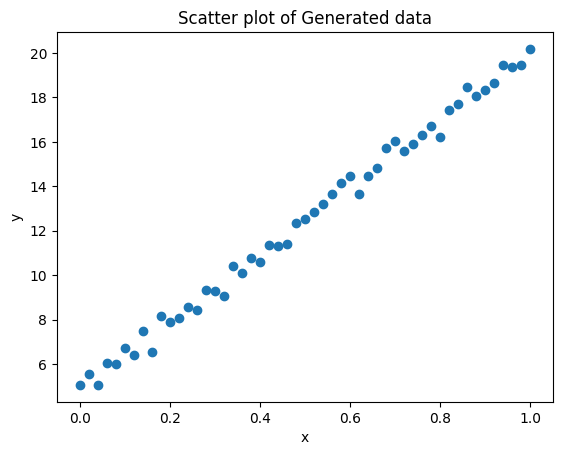

In [6]:
#plt.scatter(x, y, marker='s')
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of Generated data")

# Linear Regression

## Linear Model / Fit / Hypothesis Function

Predicted output, $\hat{y}$ is:

$$
h(x) = \hat{y} = w_0 + w_1x
$$

## Finding Linear Regression Coefficients using Gradient Descent

- We have $m$ data points $(x^{(i)}, y^{(i)}) \hspace{1cm} i = 1, 2, \cdots, m$.
- Guess $w_0$ and $w_1$.
- For any guess of $w$, we have the corresponding predicted output
$$\hat{y}^{(i)} = w_0 + w_1 x^{(i)}$$

- Calculate the cost, $C(w_0, w_1)$.
- Improve coefficients / weights by using:

$$ w_0^{iter} = w_0^{iter-1} + \delta{w_0} = w_0^{iter-1} - \eta \frac{\partial C}{\partial w_0}$$

$$ w_1^{iter} = w_1^{iter-1} + \delta{w_1} = w_1^{iter-1} - \eta \frac{\partial C}{\partial w_1}$$

- Stop when the stopping criterion is met.

## Cost Function : MSE Cost Function

$(x^{(i)}, y^{(i)})$ : $i^{th}$ "example" of (input, output) set

$m$ : Number of examples or data points

$$C(\hat{y}) = \frac{1}{2m}\sum_{i=1}^m(y^{(i)}-\hat{y}^{(i)})^2$$
$$C(w_0, w_1) = \frac{1}{2m}\sum_{i=1}^m(y^{(i)}-w_0-w_1x^{(i)})^2$$

## Gradients of the Cost Function

$$\frac{\partial C}{\partial w_0} = -\frac{1}{m} \sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)}) = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - w_0 - w_1 x^{(i)})$$

$$\frac{\partial C}{\partial w_1} = -\frac{1}{m} \sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)}) x^{(i)} = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - w_0 - w_1 x^{(i)})x^{(i)}$$    

## Gradient Descent Algorithm

1. Decide $\eta$ and $\epsilon$ and stopping criterion.
2. Make initial guess for the weights / co-efficients $w_0$ and $w_1$.
3. Calculate:

$$w_0^{(k+1)} = w_{0}^{(k)} - \frac{\eta}{m} \sum_{i=0}^{m}(y^{(i)} - \hat{y}^{(i)})$$

$$w_1^{(k+1)} = w_{1}^{(k)} - \frac{\eta}{m} \sum_{i=0}^{m}(y^{(i)} - \hat{y}^{(i)}) x^{(i)}$$

4. Check the stopping criterion:
   1. If condition is satified, then stop.
   2. If not satisfied, go to Step 3. 

## Stopping Criterion

The stopping criteria that we will use is 

$$error < \epsilon$$

Where $error$ could be:
$$error = |w_0^{iter} - w_0^{iter-1}|$$
$$error = |w_1^{iter} - w_1^{iter-1}|$$

or

$$error = |C^{iter} - C^{iter-1}|$$

## Set hyper parameters

In [7]:
eta = 0.1       # learning rate
eps = 1.e-4     # Stopping tolerance

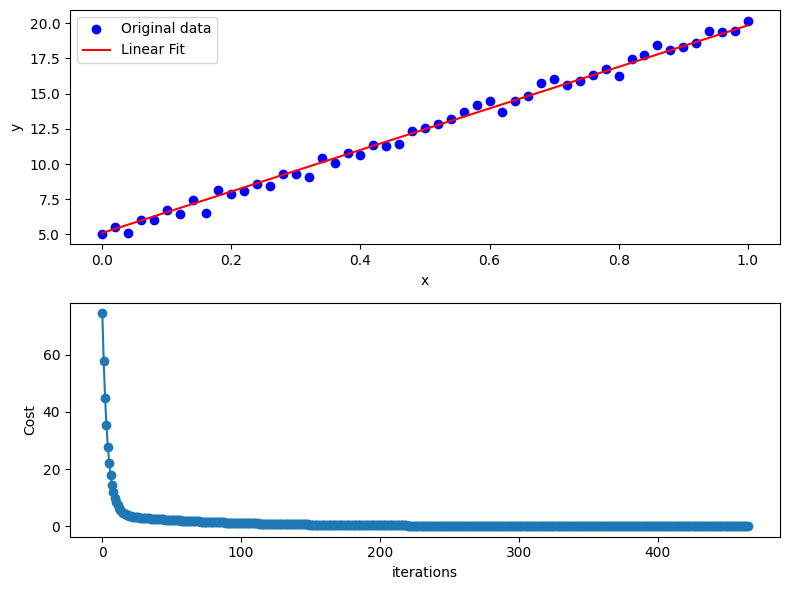

In [8]:
eta = 0.1

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0


while error > eps:

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [9]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")
print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 0.1
Number of iterations = 465
w0 = 5.104029791766209
w1 = 14.741380641568757
Cost = 0.06532653507736406


## Stopping criteria using co-efficients / weights

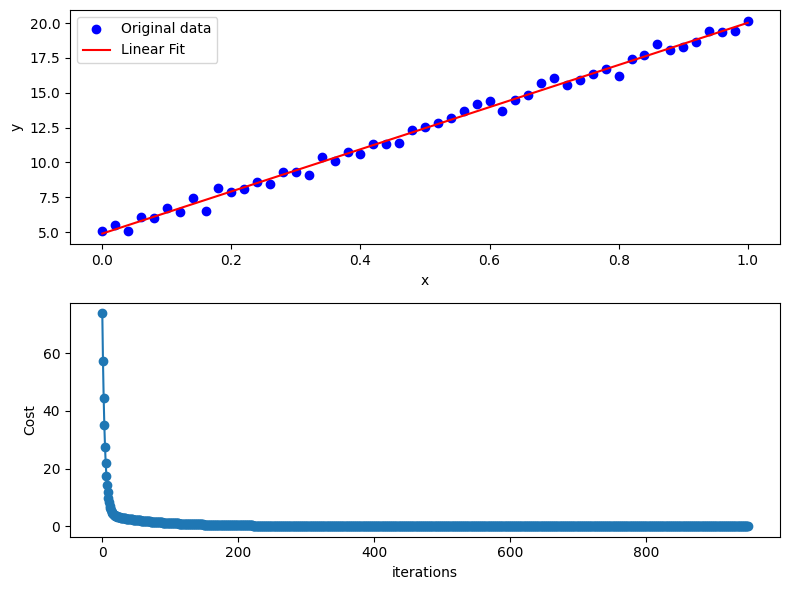

In [10]:
eta = 0.1       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [11]:
#Results
print(f"Learning Rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

Learning Rate = 0.1
Number of iterations = 950
w0 = 4.894316743843299
w1 = 15.132146925090316
Cost = 0.058109712496719666


## Faster learning

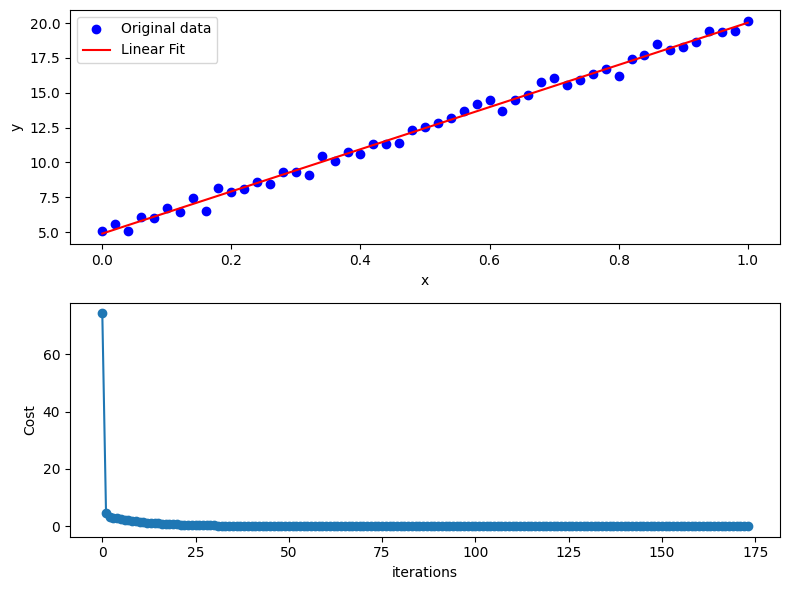

In [12]:
eta = 0.7       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [13]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 0.7
Number of iterations = 173
w0 = 4.887621736675194
w1 = 15.144621986108891
Cost = 0.05810068731142956


## Diverging Solution

C:\Users\adeet\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\adeet\AppData\Local\Temp\ipykernel_752\4003446002.py:30: RuntimeWarning: overflow encountered in square
  cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
C:\Users\adeet\AppData\Local\Temp\ipykernel_752\4003446002.py:20: RuntimeWarning: invalid value encountered in multiply
  nabla_w1 = -np.sum((y - yhat) * x) / m
C:\Users\adeet\AppData\Local\Temp\ipykernel_752\4003446002.py:25: RuntimeWarning: invalid value encountered in scalar add
  w0 = w0 + dw0


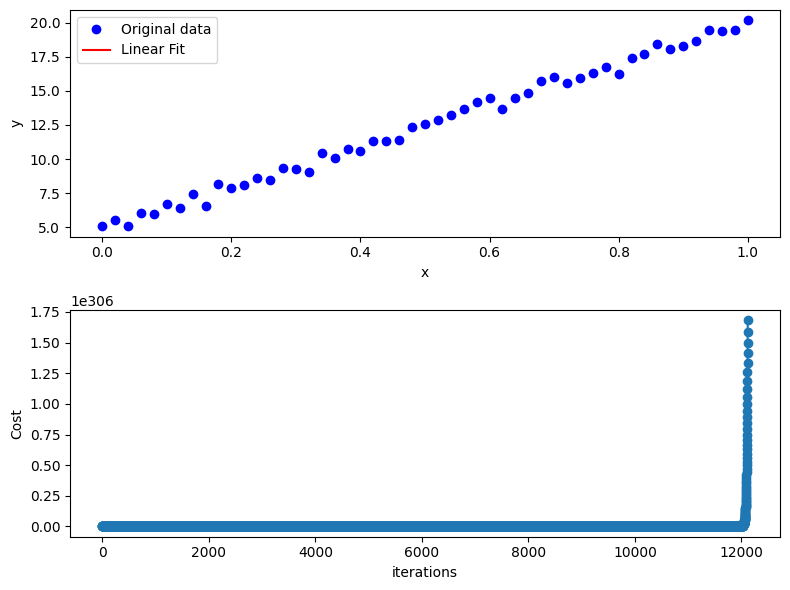

In [14]:
eta = 1.6       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [15]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 1.6
Number of iterations = 24329
w0 = nan
w1 = nan
Cost = nan
